In [67]:
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

In [39]:
df = pd.read_csv(fr"C:\ML\DataBases\russian_toxic_comments.csv", sep=",")
df

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


In [41]:
df['toxic'] = df['toxic'].apply(int)
df

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1
1,"Хохлы, это отдушина затюканого россиянина, мол...",1
2,Собаке - собачья смерть\n,1
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1


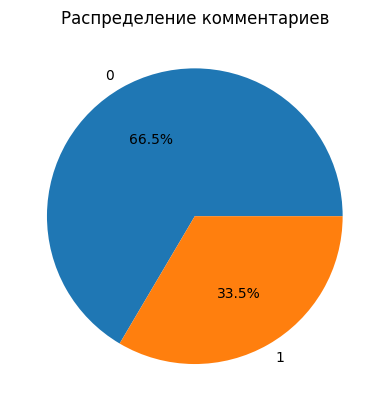

In [46]:
df['toxic'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение комментариев')
plt.axis('off');

In [49]:
for true_value in df[df['toxic'] == 1]['comment'].head(5):
    print(true_value)

Верблюдов-то за что? Дебилы, бл...

Хохлы, это отдушина затюканого россиянина, мол, вон, а у хохлов еще хуже. Если бы хохлов не было, кисель их бы придумал.

Собаке - собачья смерть

Страницу обнови, дебил. Это тоже не оскорбление, а доказанный факт - не-дебил про себя во множественном числе писать не будет. Или мы в тебя верим - это ты и твои воображаемые друзья?

тебя не убедил 6-страничный пдф в том, что Скрипалей отравила Россия? Анализировать и думать пытаешься? Ватник что ли?)



In [54]:
for false_value in df[df['toxic'] == 0]['comment'].head(5):
    print(false_value)

В шапке были ссылки на инфу по текущему фильму марвел. Эти ссылки были заменены на фразу Репортим брипидора, игнорируем его посты. Если этого недостаточно, чтобы понять, что модератор абсолютный неадекват, и его нужно лишить полномочий, тогда эта борда пробивает абсолютное дно по неадекватности.

Почитайте посты у этого автора,может найдете что нибудь полезное. Надеюсь помог) https: pikabu.ru story obyichnyie budni dezsluzhbyi 4932098

Про графику было обидно) я так то проходил все серии гта со второй части по пятую, кроме гта 4. И мне не мешала графика ни в одной из частей. На компе у меня было куча видеокарт. Начиная с 32мб RIVA TNT и заканчивая 2Гб 560Ti на которой я спокойно играю который год в танки, гта5, ведьмака3 купил на распродаже и начал проходить. Да, не на ультрах. С пониженными текстурами. И не мешает. Я не понимаю дрочева на графике, требовать графику уровня плойки 4 минимум. Мне надо чтобы глаза не резало, только и всего. По поводу управления, мне не хватает переходника

In [57]:
train_df, test_df = train_test_split(df, test_size=500, random_state=0, shuffle=True)

In [58]:
train_df['toxic'].value_counts()

toxic
0    9240
1    4672
Name: count, dtype: int64

In [59]:
test_df['toxic'].value_counts()

toxic
0    346
1    154
Name: count, dtype: int64

In [64]:
def process_text(sentence):
    tokens = word_tokenize(sentence, language='russian')
    tokens = [i for i in tokens if i not in string.punctuation]
    stop_words = stopwords.words('russian')
    tokens = [word for word in tokens if word not in stop_words]
    stemmer = SnowballStemmer(language='russian')
    res = [stemmer.stem(i) for i in tokens]
    return res

In [65]:
process_text(train_df['comment'][0])

['верблюдов-т', 'дебил', 'бл', '...']

In [69]:
param_grid = {'C': [0.1, 1.0, 10.0]}

model = Pipeline([
    ('vectorizer', TfidfVectorizer(tokenizer=lambda x: process_text(x))),
    ('model', GridSearchCV(LogisticRegression(random_state=0, max_iter=200),
                           cv=3,
                           verbose=4,
                           param_grid=param_grid))
])
model.fit(train_df['comment'], train_df['toxic'])

c:\Python\python_3.11.8\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3] END .............................C=0.1;, score=0.686 total time=   0.0s
[CV 2/3] END .............................C=0.1;, score=0.687 total time=   0.0s
[CV 3/3] END .............................C=0.1;, score=0.685 total time=   0.0s
[CV 1/3] END .............................C=1.0;, score=0.830 total time=   0.0s
[CV 2/3] END .............................C=1.0;, score=0.843 total time=   0.0s
[CV 3/3] END .............................C=1.0;, score=0.838 total time=   0.0s
[CV 1/3] END ............................C=10.0;, score=0.853 total time=   0.0s
[CV 2/3] END ............................C=10.0;, score=0.866 total time=   0.1s
[CV 3/3] END ............................C=10.0;, score=0.870 total time=   0.1s


Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(tokenizer=<function <lambda> at 0x0000022289973D80>)),
                ('model',
                 GridSearchCV(cv=3,
                              estimator=LogisticRegression(max_iter=200,
                                                           random_state=0),
                              param_grid={'C': [0.1, 1.0, 10.0]}, verbose=4))])

In [70]:
C = 10

In [71]:
model = Pipeline([
    ('vectorizer', TfidfVectorizer(tokenizer=lambda x: process_text(x))),
    ('model', LogisticRegression(random_state=0, max_iter=200, C=C))
])
model.fit(train_df['comment'], train_df['toxic'])

c:\Python\python_3.11.8\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(tokenizer=<function <lambda> at 0x0000022285D9B920>)),
                ('model',
                 LogisticRegression(C=10, max_iter=200, random_state=0))])

In [76]:
print(f"Precision: {precision_score(test_df['toxic'], model.predict(test_df['comment']))}")
print(f"Recall: {recall_score(test_df['toxic'], model.predict(test_df['comment']))}")

Precision: 0.8931297709923665
Recall: 0.7597402597402597


In [78]:
prec, rec, thresolds = precision_recall_curve(test_df['toxic'],
                                              model.predict_proba(test_df['comment'])[:, 1])

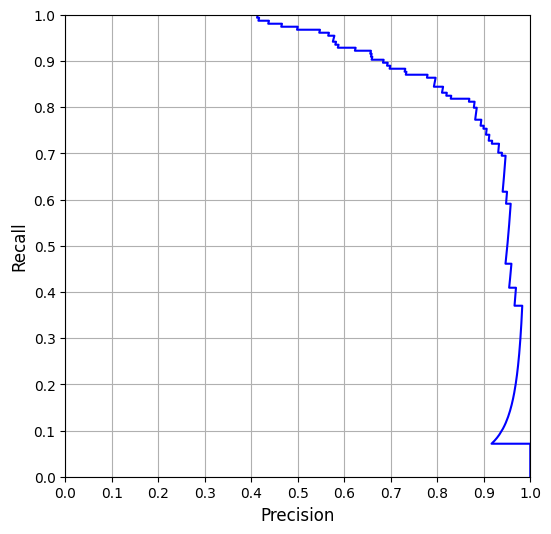

In [83]:
plt.figure(figsize=(6, 6))
plt.grid(True)
plt.plot(prec, rec, color='blue')
plt.xlabel('Precision', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.linspace(0, 1, 10 + 1))
plt.yticks(np.linspace(0, 1, 10 + 1))
plt.show();

In [124]:
demand_prec = 0.93

In [125]:
demand_index = np.min(np.where(prec > demand_prec))
demand_index

380

In [126]:
print(f"Precision: {precision_score(test_df['toxic'], model.predict_proba(test_df['comment'])[:, 1] > thresolds[demand_index])}")
print(f"Recall: {recall_score(test_df['toxic'], model.predict_proba(test_df['comment'])[:, 1] > thresolds[demand_index])}")

Precision: 0.9322033898305084
Recall: 0.7142857142857143
